# Linear Regression

Implemented linear regression from scratch here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ds = pd.read_csv("Salary_Data.csv")
X = ds["YearsExperience"].values
Y = ds["Salary"].values

In [3]:
X

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [4]:
Y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

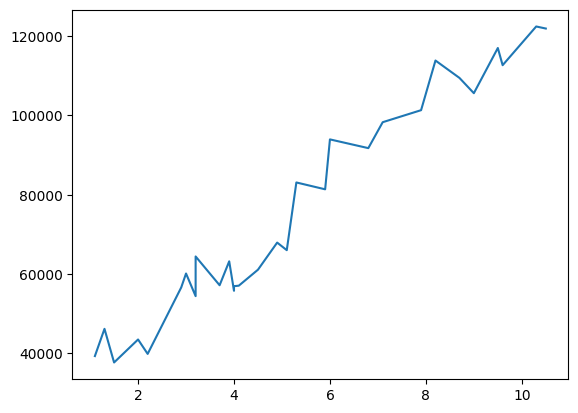

In [5]:
plt.plot(X,Y)

In [6]:
X = np.array(X)
Y = np.array(Y)

### Normalizing the dataset

In [7]:
def mean(X):
    return np.sum(X)/len(X)

### Variance

In [8]:
def variance(X):
    mean_value = mean(X)
    return np.sum((X-mean_value)**2)/len(X)

### Norm

In [9]:
def norm(X):
    mean_value = mean(X)
    variance_value = variance(X)
    return (X - mean_value)/np.sqrt(variance_value)

In [10]:
X_norm = norm(X)

In [11]:
X_norm

array([-1.51005294, -1.43837321, -1.36669348, -1.18749416, -1.11581443,
       -0.86493538, -0.82909552, -0.75741579, -0.75741579, -0.57821647,
       -0.50653674, -0.47069688, -0.47069688, -0.43485702, -0.29149756,
       -0.1481381 , -0.07645838, -0.00477865,  0.21026054,  0.2461004 ,
        0.53281931,  0.6403389 ,  0.92705781,  1.03457741,  1.21377673,
        1.32129632,  1.50049564,  1.5363355 ,  1.78721455,  1.85889428])

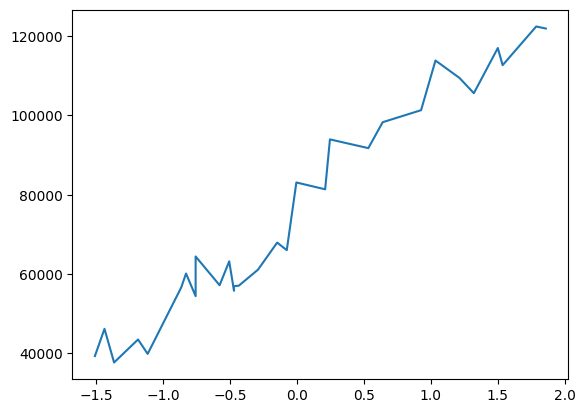

In [12]:
plt.plot(X_norm,Y)

In [13]:
import random

In [14]:
class SimpleLR:
    def __init__(self, lr=0.1, max_iter=2000, threshold=1e-6):
        self.lr = lr
        self.max_iter = max_iter
        self.threshold = threshold
        self.weight = random.uniform(-1,1)
        self.bias = random.uniform(-1,1)
    def predict(self, X):
        return self.weight*X + self.bias
    def fit(self, X, Y):
        n = len(X)
        loss_history = []
        y_pred = self.predict(X)
        errors = Y - y_pred
        prev_loss = (1/(2*n)) * np.sum(errors**2)
        loss_history.append(prev_loss)
        for i in range(self.max_iter):
            w_grad = (1/n) * np.sum(errors*X)
            b_grad = (1/n) * np.sum(errors)
            self.weight += self.lr * w_grad
            self.bias += self.lr * b_grad
            y_pred = self.predict(X)
            errors = Y-y_pred
            curr_loss = (1/(2*n)) * np.sum(errors**2)
            if np.abs(curr_loss - prev_loss) < self.threshold:
                break
            previous_loss = curr_loss
            loss_history.append(curr_loss)
        return loss_history
    def plot(self, X, Y):
        y_pred = self.predict(X)
        plt.plot(X, Y)
        plt.plot(X, y_pred)

In [15]:
model = SimpleLR()

In [16]:
loss_history = model.fit(X_norm, Y)

In [17]:
loss_history

[np.float64(3251534279.7250133),
 np.float64(2636713506.990878),
 np.float64(2138708681.0762281),
 np.float64(1735324772.0853615),
 np.float64(1408583805.8027592),
 np.float64(1143923623.1138515),
 np.float64(929548875.1358365),
 np.float64(755905329.2736442),
 np.float64(615254057.1252688),
 np.float64(501326526.68508434),
 np.float64(409045227.02853495),
 np.float64(334297374.30673003),
 np.float64(273751613.602068),
 np.float64(224709547.4312917),
 np.float64(184985473.832963),
 np.float64(152808974.21831667),
 np.float64(126746009.53045323),
 np.float64(105635008.13328384),
 np.float64(88535097.00157662),
 np.float64(74684168.98489372),
 np.float64(63464917.29138064),
 np.float64(54377323.41963504),
 np.float64(47016372.38352112),
 np.float64(41054002.04426882),
 np.float64(36224482.06947443),
 np.float64(32312570.889890958),
 np.float64(29143922.834428336),
 np.float64(26577317.909503646),
 np.float64(24498367.92031466),
 np.float64(22814418.429071553),
 np.float64(21450419.341164

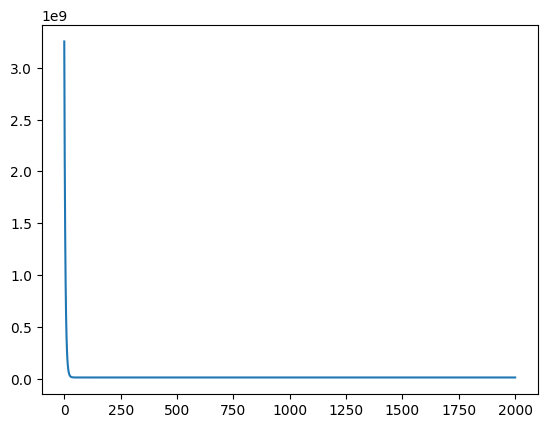

In [18]:
plt.plot(loss_history)

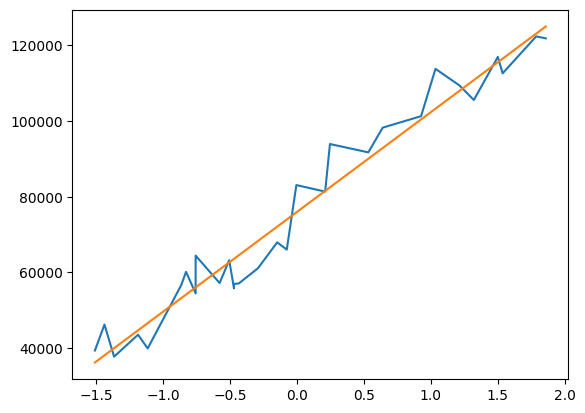

In [19]:
model.plot(X_norm,Y)